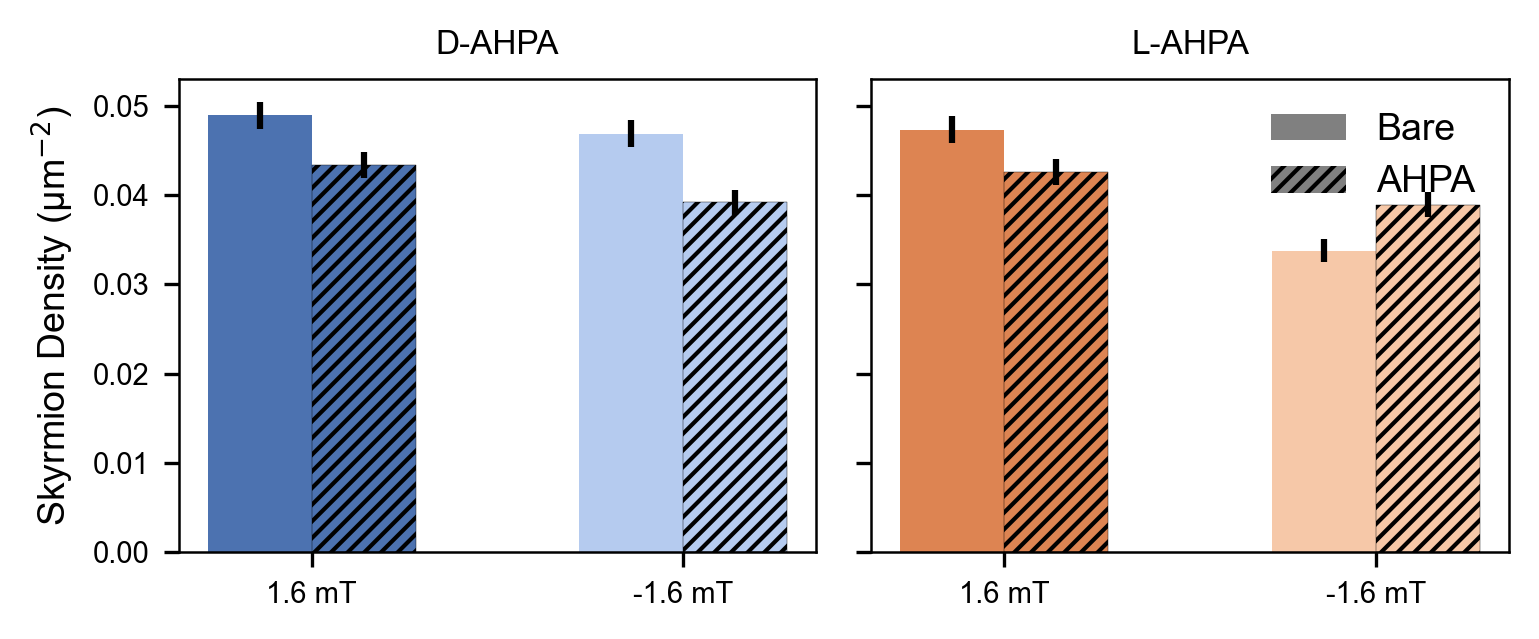

In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ==============================
# Matplotlib styling
# ==============================
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
    "font.size": 9,
    "axes.linewidth": 0.6,
    "axes.labelsize": 9,
    "axes.titlesize": 8,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
    "figure.dpi": 300,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
})

# ==============================
# Paths
# ==============================

base_dir_pos = r"/Users/buddhikadezoysa/Downloads/Supplimantary/stats/Bz_1"
base_dir_neg = r"/Users/buddhikadezoysa/Downloads/Supplimantary/stats/-Bz_1"

#base_dir_pos = r"/Users/buddhikadezoysa/Downloads/Supplimantary/stats/Bz_2"
#base_dir_neg = r"/Users/buddhikadezoysa/Downloads/Supplimantary/stats/-Bz_2"

#base_dir_pos = r"/Users/buddhikadezoysa/Downloads/Supplimantary/stats/Bz_3"
#base_dir_neg = r"/Users/buddhikadezoysa/Downloads/Supplimantary/stats/-Bz_3"

# ==============================
# Field of view (µm)
# ==============================
FOV_x = 142
FOV_y = 142
area = FOV_x * FOV_y  # µm²

# ==============================
# Dataset definitions
# ==============================
datasets = {
    "D": {
        "Bare": {"sk": "skPD.csv"},
        "AHPA": {"sk": "skD.csv"}
    },
    "L": {
        "Bare": {"sk": "skPL.csv"},
        "AHPA": {"sk": "skL.csv"}
    }
}

# ==============================
# Compute density
# ==============================
def get_density(base_dir, chem, state):

    df = pd.read_csv(os.path.join(base_dir, datasets[chem][state]["sk"]))
    diam_col = [c for c in df.columns if "Skyrmion diameter" in c][0]

    N = len(df[diam_col].dropna())

    rho = N / area
    rho_err = np.sqrt(N) / area

    return rho, rho_err

# ==============================
# Prepare data
# ==============================
def compute_density_data(chem):

    data = {}

    for field, base_dir in {
        "+1.6 mT": base_dir_pos,
        "-1.6 mT": base_dir_neg
    }.items():

        for state in ["Bare", "AHPA"]:
            rho, err = get_density(base_dir, chem, state)
            data[(field, state)] = (rho, err)

    return data

# ==============================
# Plot function
# ==============================
def plot_panel(ax, chem, colors):

    data = compute_density_data(chem)

    group_positions = np.array([0, 1])  # +Bz, -Bz
    width = 0.28

    # Extract values
    bare_vals = [data[("+1.6 mT","Bare")][0],
                 data[("-1.6 mT","Bare")][0]]

    bare_err = [data[("+1.6 mT","Bare")][1],
                data[("-1.6 mT","Bare")][1]]

    ahpa_vals = [data[("+1.6 mT","AHPA")][0],
                 data[("-1.6 mT","AHPA")][0]]

    ahpa_err = [data[("+1.6 mT","AHPA")][1],
                data[("-1.6 mT","AHPA")][1]]

    # ---- Plot Bare ----
    bars_bare = ax.bar(
        group_positions - width/2,
        bare_vals,
        width,
        yerr=bare_err,
        color=[colors["+1.6 mT"], colors["-1.6 mT"]],
        label="Bare"
    )

    # ---- Plot AHPA ----
    bars_ahpa = ax.bar(
        group_positions + width/2,
        ahpa_vals,
        width,
        yerr=ahpa_err,
        color=[colors["+1.6 mT"], colors["-1.6 mT"]],
        label="AHPA"
    )

    # Apply hatching to AHPA only
    for bar in bars_ahpa:
        bar.set_hatch("//////")
        bar.set_edgecolor("black")
        bar.set_linewidth(0.1)

    # Axis formatting
    ax.set_xticks(group_positions)
    ax.set_xticklabels(["1.6 mT", "-1.6 mT"])
    ax.set_title(f"{chem}-AHPA")

# ==============================
# Colors
# ==============================
colors_D = {
    "+1.6 mT": "#4C72B0",
    "-1.6 mT": "#B5CBEF"
}

colors_L = {
    "+1.6 mT": "#DD8452",
    "-1.6 mT": "#F6C8A8"
}

# ==============================
# Create figure
# ==============================
fig, axes = plt.subplots(1, 2, figsize=(5.2, 2.2), sharey=True)

# D panel
plot_panel(axes[0], "D", colors_D)
axes[0].set_ylabel("Skyrmion Density (µm$^{-2}$)")

# L panel
plot_panel(axes[1], "L", colors_L)

# Custom legend
legend_handles = [
    plt.Rectangle((0,0),1,1,facecolor="gray", hatch="", label="Bare"),
    plt.Rectangle((0,0),1,1,facecolor="gray", hatch="//////", label="AHPA")
]

axes[1].legend(handles=legend_handles, loc="upper right", frameon=False)

plt.tight_layout()
plt.savefig("Skyrmion_Density_Comparison_PRL.pdf")
plt.savefig("Skyrmion_Density_Comparison_PRL.eps")
plt.show()